In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
def plot_benchmark(df, title="Model Benchmark Comparison", palette="muted"):
    """
    Plot benchmark comparison across three metrics: latency, FPS, and memory.

    Args:
        df         : DataFrame with columns [model, threads, avg_ms, fps, max_rss_mb]
        title      : Overall figure title
        palette    : Seaborn color palette
    """
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(title, fontsize=16, fontweight="bold", y=1.02)

    metrics = [
        ("avg_ms",     axes[0], "Average Latency (ms)",   "Latency (ms)"),
        ("fps",        axes[1], "Frames Per Second (FPS)", "FPS"),
        ("max_rss_mb", axes[2], "Memory Footprint (MB)",  "Peak RAM (MB)"),
    ]

    for col, ax, title_, ylabel in metrics:
        sns.barplot(ax=ax, data=df, x="threads", y=col, hue="model", palette=palette)
        ax.set_title(title_)
        ax.set_ylabel(ylabel)
        ax.set_xlabel("Threads")
        ax.legend(title="Model", fontsize=8, title_fontsize=9)

    plt.tight_layout()
    plt.show()

# aarch64

In [6]:
# Read the CSV data
df_aarch64 = pd.read_csv("aarch64_benchmark_results.csv")
df_aarch64

,model,threads,avg_ms,fps,max_rss_mb
0,yolo26n_float16.tflite,1,197.96,5.05,42.62
1,yolo26n_float16.tflite,2,118.42,8.44,42.90
2,yolo26n_float16.tflite,4,86.68,11.54,42.73
3,yolo26n_float32.tflite,1,196.99,5.08,36.09
4,yolo26n_float32.tflite,2,119.57,8.36,36.18
5,yolo26n_float32.tflite,4,86.73,11.53,35.97
6,yolo26n_int8.tflite,1,222.12,4.50,22.01
7,yolo26n_int8.tflite,2,133.57,7.49,21.77
8,yolo26n_int8.tflite,4,99.73,10.03,21.70


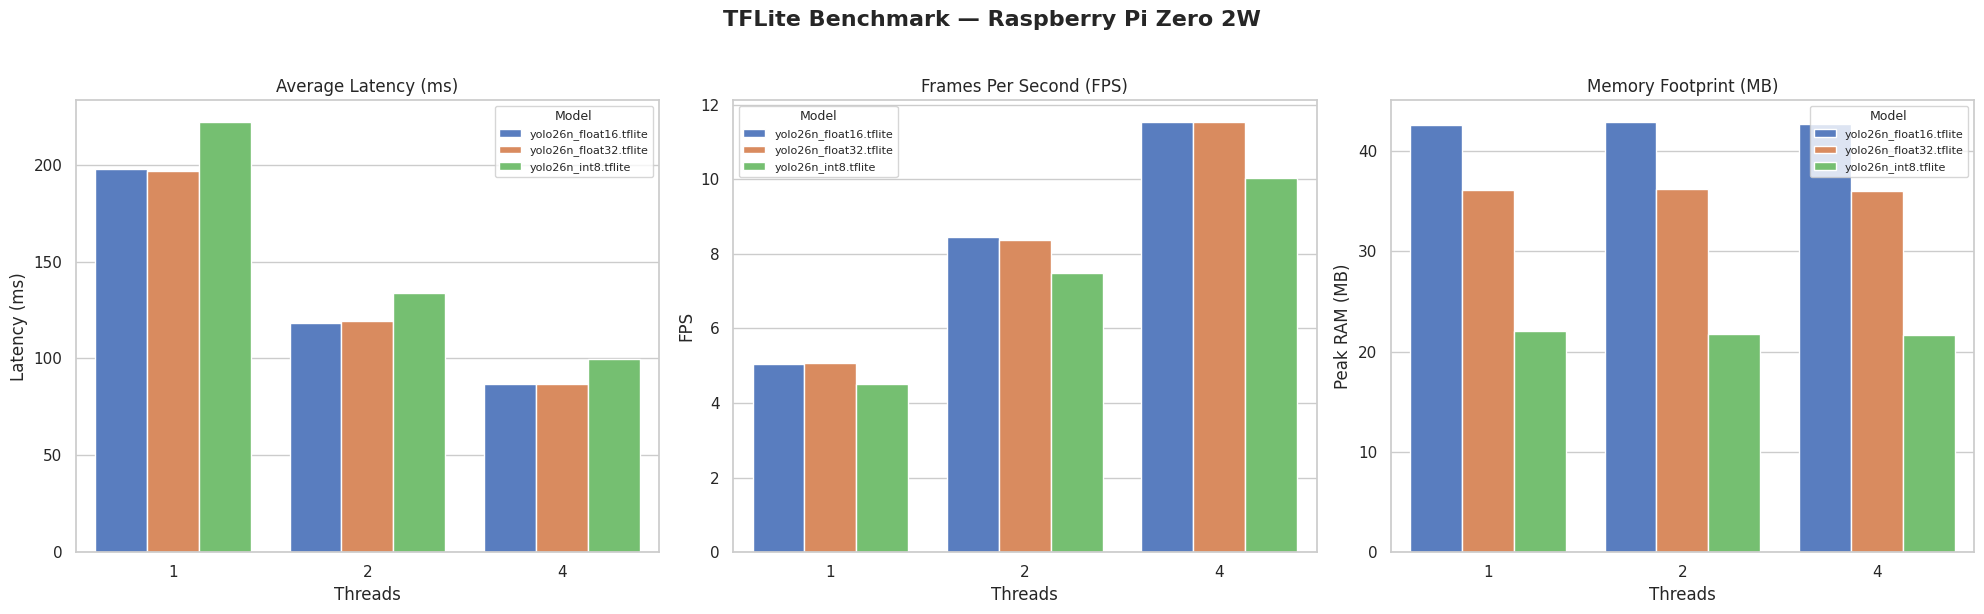

In [7]:
plot_benchmark(df_aarch64, title="TFLite Benchmark — Raspberry Pi Zero 2W")

In [8]:
# Print the best configuration
best_fps = df_aarch64.loc[df_aarch64["fps"].idxmax()]
print("\n--- Benchmark Analysis ---\n")
print(
    f"Best Performance Configuration: {best_fps['model']} with {best_fps['threads']} threads ({best_fps['fps']:.2f} FPS)"
)



--- Benchmark Analysis ---

Best Performance Configuration: yolo26n_float16.tflite with 4 threads (11.54 FPS)
